In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import cross_val_score, train_test_split

sns.set()

# Árboles de decisión
## Árboles de regresión
**Aprendizaje de Máquina - CEIA - FIUBA**

Como vimos en clase, un árbol de decisión sirve para hacer regresiones. Scikit-learn nos ofrece la clase [`DecisionTreeRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html), que es la implementación del árbol de regresión.

Para practicar este modelo vamos a usar el dataset **Hitters**, el mismo que usamos en la clase de SVM. Contiene datos de jugadores de béisbol de la liga estadounidense de 1986 y 1987 (322 observaciones con 20 atributos). Lo que queremos es predecir el salario de 1987 de cada jugador usando como base sus estadísticas de la temporada 1986. El significado de cada variable está [explicado aquí](https://rdrr.io/cran/ISLR/man/Hitters.html).

> El análisis exploratorio completo del dataset (distribución del target, justificación de la transformación logarítmica, correlaciones, multicolinealidad y el baseline) está en la notebook auxiliar [`clase3/jupyter_notebooks/EDA - Hitters.ipynb`](../../clase3/jupyter_notebooks/EDA%20-%20Hitters.ipynb). Acá nos quedamos con el preprocesamiento y el modelado.

Vamos a usar **el mismo preprocesamiento y el mismo split** (`test_size=0.3`, `random_state=42`) que en la notebook de SVR de la clase 3, para poder comparar el árbol de regresión contra todos los modelos que ya entrenamos sobre este dataset.

In [2]:
# Cargamos el dataset
df_hitters = pd.read_csv("datasets/Hitters.csv")

In [3]:
df_hitters.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    str    
 14  Division   322 non-null    str    
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    str    
dtypes: float64(1), int64(

In [4]:
df_hitters.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


Como los datos de salario no están completos, descartamos a los jugadores que no tienen ese dato.

In [5]:
df_hitters.dropna(subset="Salary", inplace=True)

Modelamos el **logaritmo del salario**: en el EDA vimos que reduce la fuerte asimetría del target y descomprime los salarios bajos.

In [6]:
df_hitters["Salary_log"] = np.log(df_hitters["Salary"])

Todas las variables son numéricas salvo *League*, *Division* y *NewLeague*, que convertimos en variables dummy:

In [7]:
df_hitters_dummies = pd.get_dummies(data=df_hitters,
                                    columns=['League', 'Division', 'NewLeague'],
                                    drop_first=True)

In [8]:
df_hitters_dummies.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors', 'Salary', 'Salary_log', 'League_N', 'Division_W',
       'NewLeague_N'],
      dtype='str')

Obtenemos los arrays. A diferencia de SVM, para el árbol vamos a usar **todos** los atributos disponibles.

In [9]:
X_cols = ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits',
          'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors',
          'League_N', 'Division_W', 'NewLeague_N']

X = df_hitters_dummies.loc[:, X_cols]
# Y como variable a predecir usamos el logaritmo del salario
y = df_hitters_dummies.loc[:, 'Salary_log']

Separamos en los conjuntos de entrenamiento y testeo (mismo split que la notebook de SVR de la clase 3).

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
    random_state=42)

Una ventaja importante de los árboles es que **no necesitamos escalar las variables**: las divisiones se hacen sobre umbrales de cada atributo por separado, así que la escala de cada variable no afecta el modelo. Esto es distinto de SVM o los modelos lineales regularizados, donde el escalado era imprescindible.

Ahora aplicamos el procedimiento que vimos: primero llamamos al modelo de [árbol de regresión](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html).

In [11]:
from sklearn.tree import DecisionTreeRegressor

# Creamos el arbol sin ninguna restricción (crecerá hasta el final)
regression = DecisionTreeRegressor(criterion='squared_error', splitter='best',
    max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=42)
# Y entrenamos
regression.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

Podemos ver cuáles son los parámetros de creación del modelo (esto sale en la documentación y es común a todos los modelos) usando `.get_params()`.

In [12]:
regression.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Podemos exportar el árbol para entender qué hizo usando [`export_graphviz`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html). El archivo `.dot` que genera se puede visualizar en [webgraphviz](http://www.webgraphviz.com/?tab=map), donde se ve la disposición de los nodos y cómo el algoritmo fue tomando las decisiones de división.

In [13]:
from sklearn.tree import export_graphviz

export_graphviz(regression, out_file="arbol_regresion.dot",
                feature_names=X_cols,
                rounded=True,
                filled=True)

También podemos verlo directamente desde sklearn con [`plot_tree`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html). Como el árbol creció sin restricciones, es enorme:

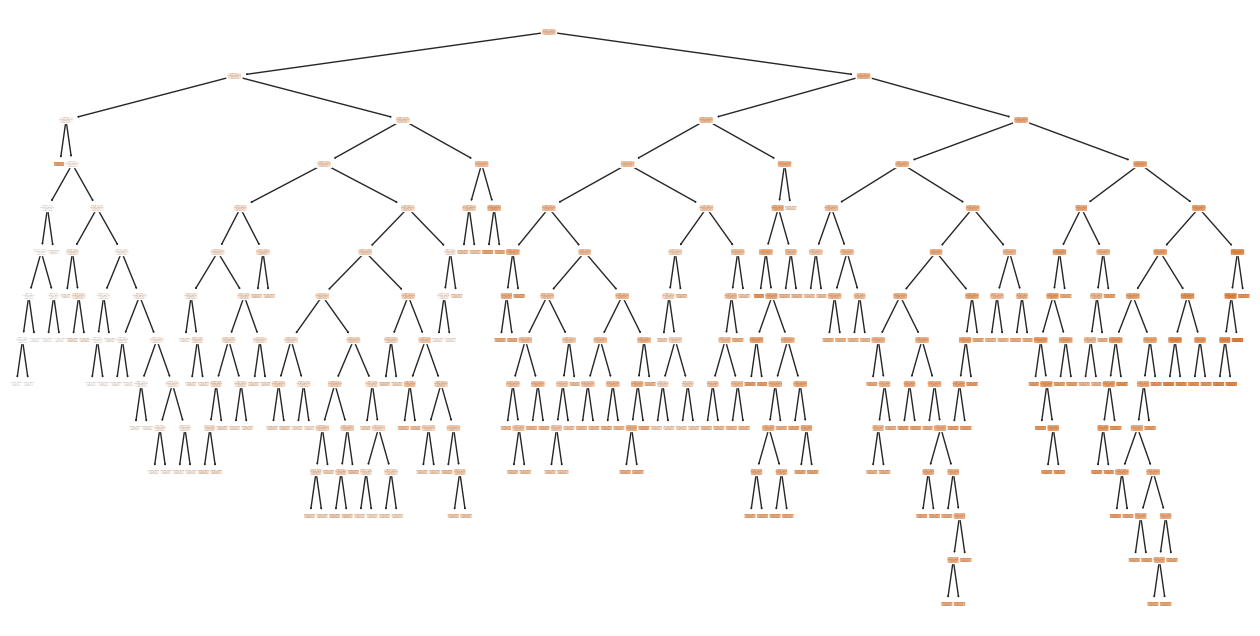

In [14]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(regression, filled=True, feature_names=X_cols, rounded=True, ax=ax);

Midamos cómo performa este modelo usando el error medio absoluto (MAE), tanto en entrenamiento como en testeo:

In [15]:
y_pred_train = regression.predict(X_train)
y_pred = regression.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae = mean_absolute_error(y_test, y_pred)

print(f"El error de entrenamiento fue: {mae_train}")
print(f"El error de testeo fue: {mae}")
print(f"Cantidad de hojas del árbol: {regression.get_n_leaves()}")

El error de entrenamiento fue: 0.0
El error de testeo fue: 0.4465765036315931
Cantidad de hojas del árbol: 169


El resultado es muy malo: el error de entrenamiento es **cero** y el árbol tiene más de 150 hojas. Esto es sobreajuste puro (era esperable, porque dejamos que cada hoja tenga una sola muestra: el árbol se memoriza el training).

----

Ahora intentemos **podar** el árbol. Para eso vamos a usar el argumento [`ccp_alpha`](https://scikit-learn.org/stable/modules/tree.html#minimal-cost-complexity-pruning), que es el $\alpha$ que vimos en clase para el *minimal cost-complexity pruning*. Buscamos el mejor valor de $\alpha$ mediante validación cruzada con 5 folds: el que logre podar el árbol minimizando lo más posible el error.

In [16]:
# Hagamos una ejecución de prueba con alpha = 0 (sin poda)
clf = DecisionTreeRegressor(criterion='squared_error', splitter='best',
                            max_depth=None, min_samples_split=2, min_samples_leaf=1,
                            random_state=42, ccp_alpha=0)

scores = np.abs(cross_val_score(clf, X_train, y_train, cv=5,
                                scoring='neg_mean_absolute_error', n_jobs=-1))
print(scores)
print(f"El valor medio de MAE cuando alfa es cero: {np.mean(scores)}")

[0.3953924  0.52913356 0.37688818 0.42036926 0.37489407]
El valor medio de MAE cuando alfa es cero: 0.41933549705650613


El error de CV (~0.37) es cercano al del set de testeo. Ahora hagamos la búsqueda de $\alpha$ recorriendo una grilla de valores de forma "manual", registrando además cuántas hojas queda teniendo el árbol para cada valor:

In [17]:
scores_list = []
alpha_array = np.linspace(0, 0.5, 200)
leaf_array = np.zeros_like(alpha_array)
for index, alpha in enumerate(alpha_array):
    clf = DecisionTreeRegressor(criterion='squared_error', splitter='best',
                                max_depth=None, min_samples_split=2,
                                min_samples_leaf=1, random_state=42, ccp_alpha=alpha)
    scores_list.append(np.abs(cross_val_score(clf, X_train, y_train, cv=5,
        scoring='neg_mean_absolute_error')))
    clf.fit(X_train, y_train)
    on_leaf = clf.apply(X_train)
    leaf_array[index] = len(np.unique(on_leaf))

scores_array = np.array(scores_list)
del scores_list

df_results = pd.DataFrame({"alpha": alpha_array,
                           "on_leaf": leaf_array,
                           "mae1": scores_array[:, 0],
                           "mae2": scores_array[:, 1],
                           "mae3": scores_array[:, 2],
                           "mae4": scores_array[:, 3],
                           "mae5": scores_array[:, 4]})

# El alpha que minimiza el MAE promedio de CV
mae_medio = scores_array.mean(axis=1)
alpha_opt = alpha_array[mae_medio.argmin()]
print(f"El alpha que minimiza el MAE de CV es: {alpha_opt:.4f}"
    f" (MAE = {mae_medio.min():.4f})")

df_results = pd.melt(df_results, id_vars=['alpha', 'on_leaf'],
    value_vars=["mae1", "mae2", "mae3", "mae4", "mae5"])

El alpha que minimiza el MAE de CV es: 0.0050 (MAE = 0.3669)


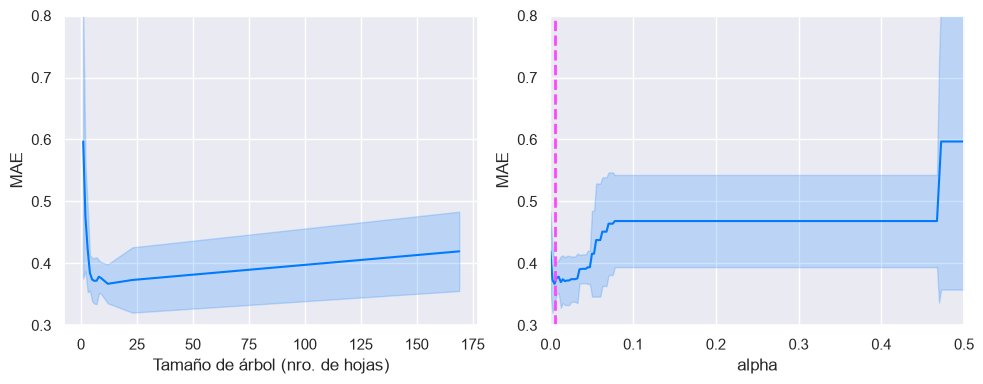

In [18]:
f, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.lineplot(data=df_results, x="on_leaf", y="value", errorbar="sd", ax=ax[0],
             color="#007aff")
sns.lineplot(data=df_results, x="alpha", y="value", errorbar="sd", ax=ax[1],
             color="#007aff")
ax[1].axvline(alpha_opt, color="#ff48fd", linestyle="--", linewidth=2)

ax[0].set_xlabel("Tamaño de árbol (nro. de hojas)")
ax[0].set_ylabel("MAE")
ax[0].set_ylim([0.3, 0.8])
ax[1].set_xlim([0, 0.5])
ax[1].set_ylim([0.3, 0.8])
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("MAE")
plt.tight_layout()
plt.show()

Nos quedamos con el valor de $\alpha$ que minimiza el MAE de validación cruzada y entrenamos el árbol podado:

In [19]:
# Creamos el arbol podado con el mejor alpha
regression = DecisionTreeRegressor(criterion='squared_error', splitter='best',
                                   max_depth=None, min_samples_split=2,
                                   min_samples_leaf=1, random_state=42,
                                   ccp_alpha=alpha_opt)
regression.fit(X_train, y_train)

y_pred_train = regression.predict(X_train)
y_pred_tree = regression.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae = mean_absolute_error(y_test, y_pred_tree)
rmse = root_mean_squared_error(y_test, y_pred_tree)
mape = mean_absolute_percentage_error(y_test, y_pred_tree)
r2 = r2_score(y_test, y_pred_tree)

print(f"MAE de entrenamiento fue: {mae_train}")
print(f"MAE de testeo fue: {mae}")
print(f"RMSE de testeo fue: {rmse}")
print(f"MAPE de testeo fue: {mape}")
print(f"R2 de testeo fue: {r2}")
print(f"Cantidad de hojas del árbol podado: {regression.get_n_leaves()}")

MAE de entrenamiento fue: 0.23092410873941685
MAE de testeo fue: 0.4696693720273872
RMSE de testeo fue: 0.6709997329483751
MAPE de testeo fue: 0.0803772828765648
R2 de testeo fue: 0.4223187374141222
Cantidad de hojas del árbol podado: 12


El árbol pasó de más de 150 hojas a apenas una docena. El error de testeo se mantiene en el mismo orden: el árbol sin podar parecía un poco mejor en este split puntual, pero tenía error de entrenamiento **cero** (puro sobreajuste, no es un número confiable). A cambio de esa diferencia mínima ganamos muchísima generalización e interpretabilidad. Ahora sí lo podemos visualizar cómodamente:

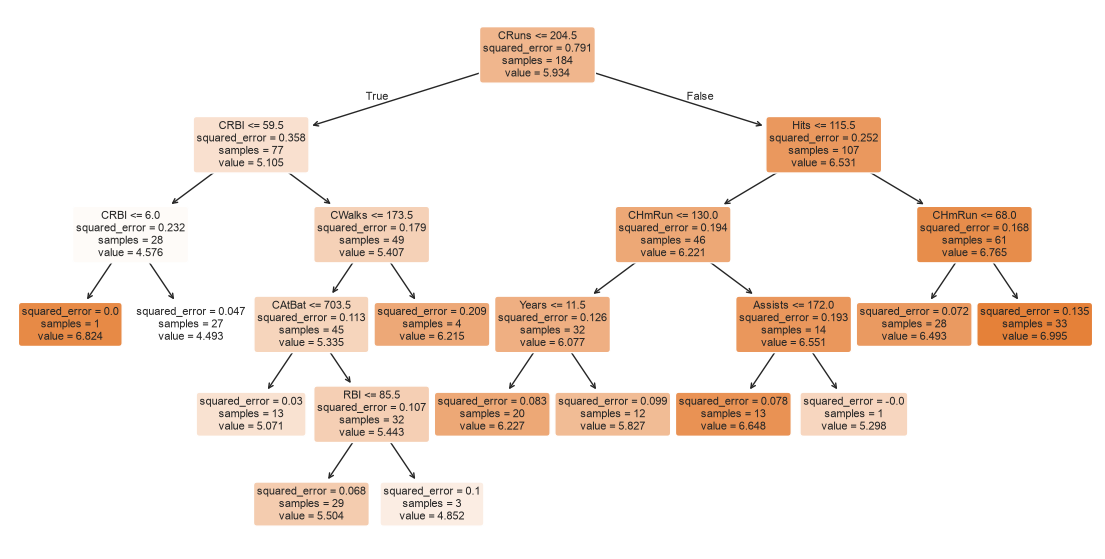

In [20]:
export_graphviz(regression, out_file="arbol_regresion_alpha.dot",
                feature_names=X_cols,
                rounded=True,
                filled=True)

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(regression, filled=True, feature_names=X_cols, rounded=True, ax=ax);

---
## Comparativa final

Reunimos todos los modelos de regresión entrenados sobre Hitters con el **mismo split** (`test_size=0.3`, `random_state=42`), para compararlos sobre el mismo conjunto de testeo:

- **Baseline (tramos de años)** — tabla de referencia que predice el salario promedio según el tramo de experiencia del jugador (definido en la notebook auxiliar [`clase3/.../EDA - Hitters.ipynb`](../../clase3/jupyter_notebooks/EDA%20-%20Hitters.ipynb)).
- **Regresión Lineal (OLS)** y **Ridge** — modelos lineales desarrollados en la notebook auxiliar [`clase3/.../Auxiliar - Regresion Lineal.ipynb`](../../clase3/jupyter_notebooks/Auxiliar%20-%20Regresion%20Lineal.ipynb).
- **SVR (RBF)** — el mejor SVR encontrado en la clase 3, reproducido acá con el mismo split.
- **Árbol de regresión (podado)** — el modelo que desarrollamos en este notebook.

La métrica principal es el **MAE** (menor es mejor).

In [21]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# X sigue siendo el DataFrame sin escalar; el árbol ya está entrenado y y_pred_tree
# fue calculado más arriba. Los modelos lineales y el SVR necesitan escalado.

# Baseline: promedio de log(Salary) por tramo de años (ver EDA - Hitters).
bins = [0, 2, 4, 6, 9, 13, np.inf]
tramo_train = pd.cut(X_train["Years"], bins=bins)
tramo_test = pd.cut(X_test["Years"], bins=bins)
prom_por_tramo = y_train.groupby(tramo_train, observed=False).mean()
y_pred_base = tramo_test.map(prom_por_tramo).astype(float).values

# Modelos lineales (mejor alpha de Ridge hallado en la notebook auxiliar de la clase 3)
ols = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
ols.fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)

ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=13.67))])
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# SVR: reproducimos la búsqueda de grilla de la clase 3
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s = sc.transform(X_test)
grid_svr = GridSearchCV(SVR(),
    [{"C": [0.01, 0.1, 1, 5, 10, 100], "kernel": ["linear"]},
     {"C": [0.01, 0.1, 1, 5, 10, 100], "gamma": [0.1, 0.5, 1, 2, 10, 100],
      "kernel": ["rbf", "sigmoid"]},
     {"C": [0.01, 0.1, 1, 5, 10, 100], "degree": [2, 3, 4, 5, 6], "kernel": ["poly"]}],
    cv=5, scoring='neg_mean_absolute_error')
grid_svr.fit(X_train_s, y_train)
y_pred_svr = grid_svr.predict(X_test_s)

modelos = ["Baseline (tramos de años)", "Regresión Lineal", "Ridge",
           "SVR (RBF)", "Árbol de regresión"]
preds = [y_pred_base, y_pred_ols, y_pred_ridge, y_pred_svr, y_pred_tree]

df_cmp = pd.DataFrame({
    "MAE": [mean_absolute_error(y_test, p) for p in preds],
    "RMSE": [root_mean_squared_error(y_test, p) for p in preds],
    "R2": [r2_score(y_test, p) for p in preds],
}, index=pd.Index(modelos))

df_cmp.round(4)

,MAE,RMSE,R2
Baseline (tramos de años),0.5068,0.7027,0.3665
Regresión Lineal,0.5154,0.6779,0.4103
Ridge,0.5118,0.6626,0.4366
SVR (RBF),0.3918,0.5702,0.5828
Árbol de regresión,0.4697,0.6710,0.4223


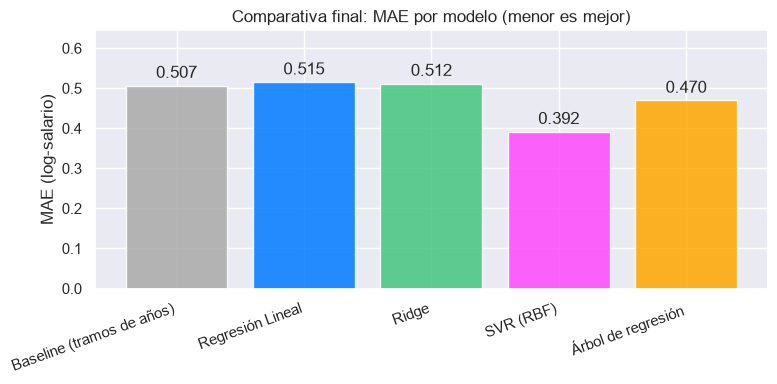

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
colores = ["#aaaaaa", "#007aff", "#44c57f", "#ff48fd", "#ffa600"]
bars = ax.bar(df_cmp.index, df_cmp["MAE"], color=colores, alpha=0.85)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_ylabel("MAE (log-salario)")
ax.set_title("Comparativa final: MAE por modelo (menor es mejor)")
ax.set_ylim(0, df_cmp["MAE"].max() * 1.25)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Observaciones

- El **SVR (RBF)** sigue siendo el mejor modelo: **MAE ≈ 0.39** y el mayor R² (≈ 0.58), muy por debajo del resto. El kernel no lineal captura relaciones que ningún otro modelo alcanza.
- El **árbol de regresión** queda en un cómodo **segundo lugar (MAE ≈ 0.47)**: mejora al baseline y a los modelos lineales (OLS y Ridge, ≈ 0.51), aunque no llega al SVR. Y lo consigue con un árbol podado de muy pocas hojas, totalmente interpretable.
- El **baseline por tramos de años** vuelve a ser sorprendentemente competitivo (**MAE ≈ 0.51**): iguala a los modelos lineales sólo mirando la experiencia del jugador. Esto confirma lo que veíamos en el EDA: buena parte de la señal "fácil" del salario está en los años de carrera.
- Que OLS y Ridge apenas se despeguen del baseline se explica por la fuerte **multicolinealidad** entre las variables de carrera, que limita lo que un modelo lineal puede aportar. El árbol, al partir el espacio de forma no lineal, logra exprimir algo más de esa señal.